Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_context("talk")

df = pd.read_csv("../HAM10000_metadata_clean.csv")

In [ ]:
print(df.describe(include='all'))

          lesion_id      image_id     dx dx_type          age    sex  \
count         10015         10015  10015   10015  9958.000000  10015   
unique         7470         10015      7       4          NaN      3   
top     HAM_0003789  ISIC_0027419     nv   histo          NaN   male   
freq              6             1   6705    5340          NaN   5406   
mean            NaN           NaN    NaN     NaN    51.863828    NaN   
std             NaN           NaN    NaN     NaN    16.968614    NaN   
min             NaN           NaN    NaN     NaN     0.000000    NaN   
25%             NaN           NaN    NaN     NaN    40.000000    NaN   
50%             NaN           NaN    NaN     NaN    50.000000    NaN   
75%             NaN           NaN    NaN     NaN    65.000000    NaN   
max             NaN           NaN    NaN     NaN    85.000000    NaN   

       localization  
count         10015  
unique           15  
top            back  
freq           2192  
mean            NaN  
std

Disease Class Distribution

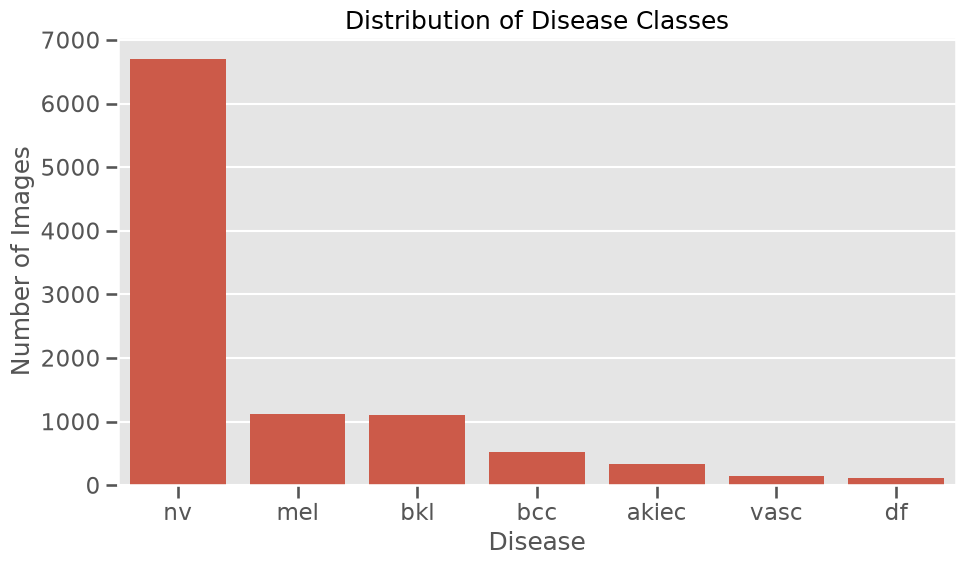

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="dx",
    order=df["dx"].value_counts().index
)

plt.title("Distribution of Disease Classes")
plt.xlabel("Disease")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

Disease Percentages

In [ ]:
disease_percent = (
    df["dx"]
    .value_counts(normalize=True)
    *100
)

print(disease_percent.round(2))

dx
nv       66.95
mel      11.11
bkl      10.97
bcc       5.13
akiec     3.27
vasc      1.42
df        1.15
Name: proportion, dtype: float64


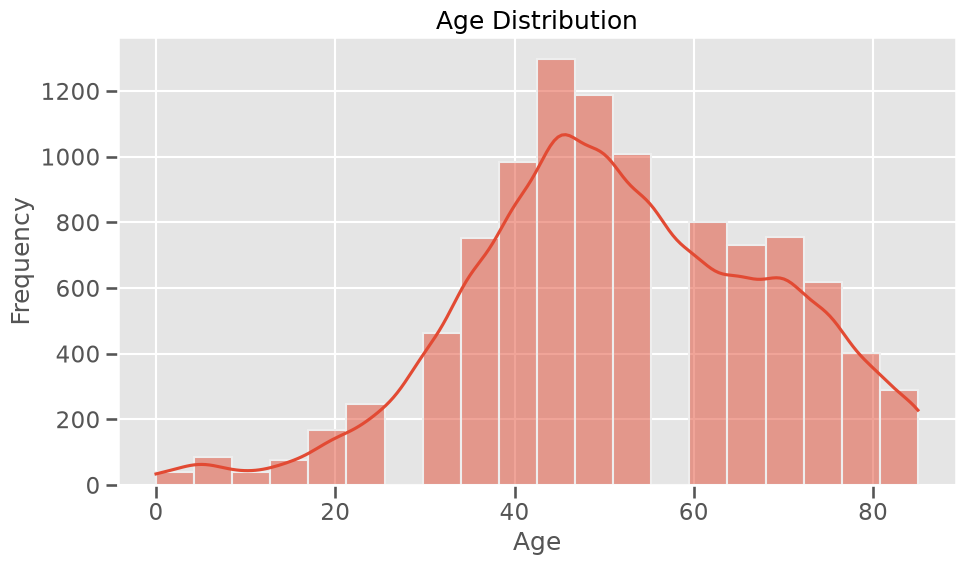

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["age"],
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

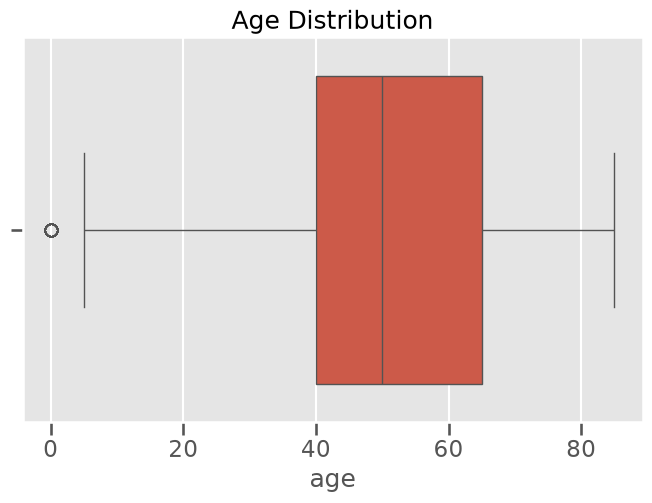

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["age"]
)

plt.title("Age Distribution")
plt.show()

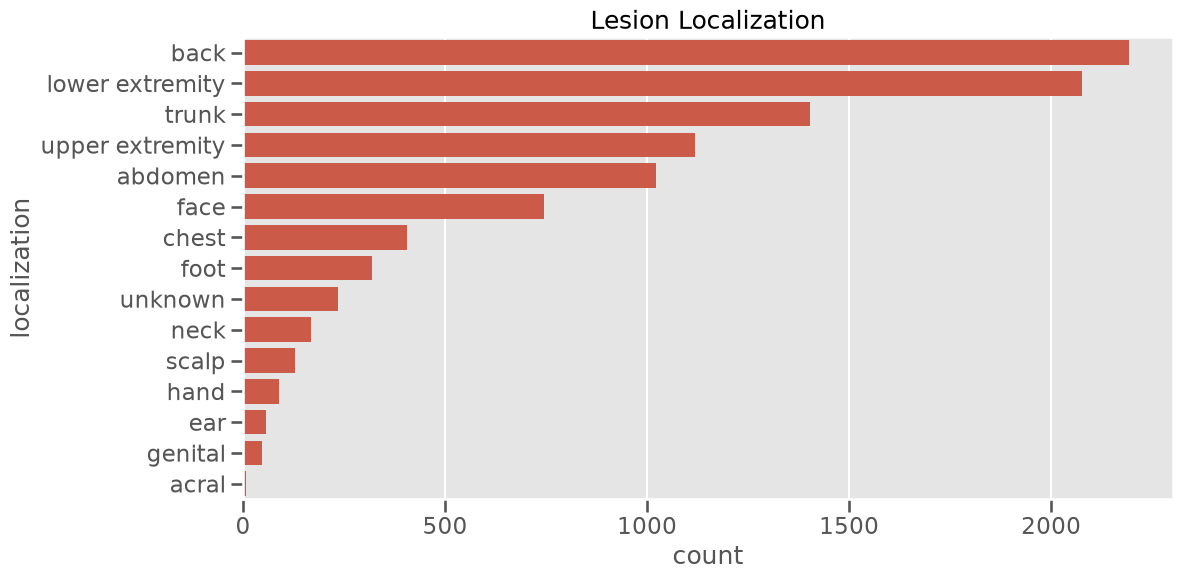

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="localization",
    order=df["localization"].value_counts().index
)

plt.title("Lesion Localization")
plt.show()

Images per Lesion

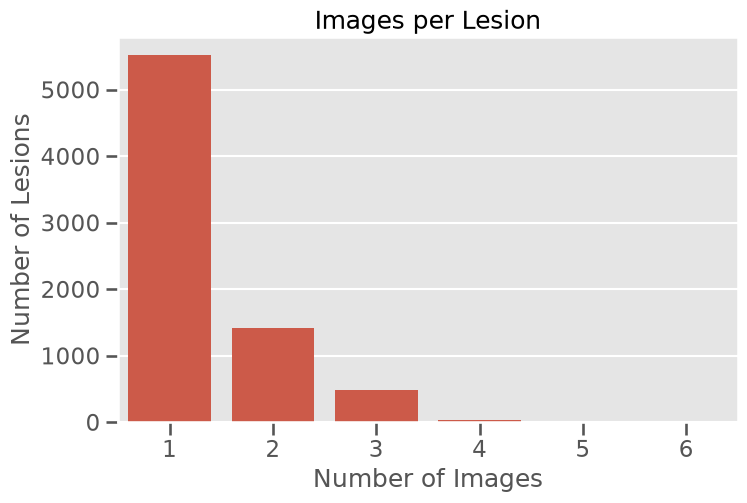

In [ ]:
lesion_counts = (
    df.groupby("lesion_id")
      .size()
)

plt.figure(figsize=(8,5))

sns.countplot(
    x=lesion_counts
)

plt.title("Images per Lesion")
plt.xlabel("Number of Images")
plt.ylabel("Number of Lesions")
plt.show()

Disease vs Sex

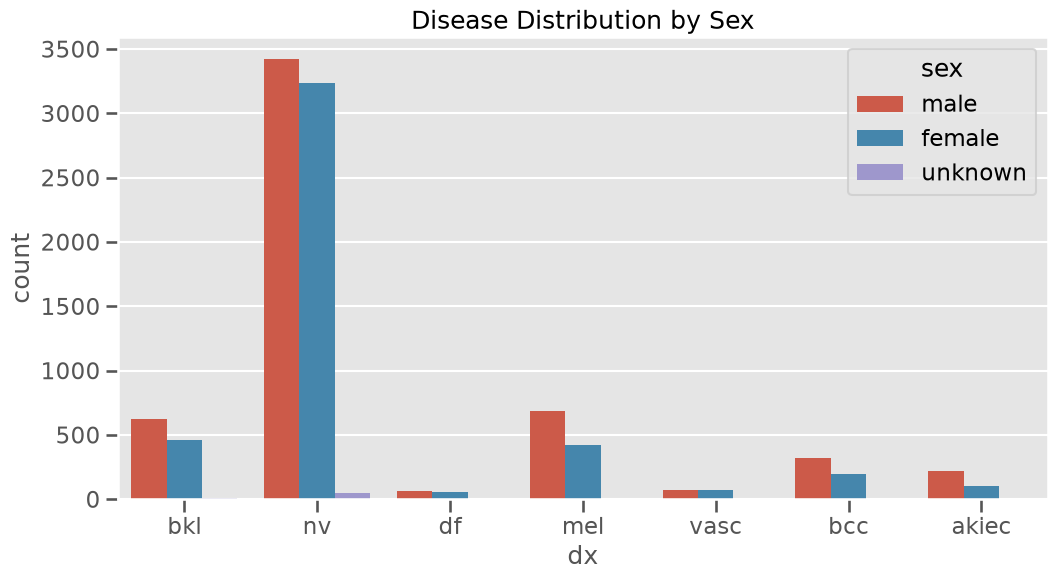

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="dx",
    hue="sex"
)

plt.title("Disease Distribution by Sex")
plt.show()

In [ ]:
df[["age"]].corr()

,age
age,1.0


Random Image Visualisation

In [ ]:
import os

folder1 = "HAM10000_images_part_1"
folder2 = "HAM10000_images_part_2"

paths = []

for img in df["image_id"]:
    file = img + ".jpg"

    p1 = os.path.join(folder1, file)
    p2 = os.path.join(folder2, file)

    if os.path.exists(p1):
        paths.append(p1)
    else:
        paths.append(p2)

df["image_path"] = paths

In [ ]:
df.to_csv("HAM10000_metadata_clean.csv", index=False)